## Visualização

Nesse notebook é construída a visualização dos resultados da análise empregada no livro.

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
from utils.load_csv import load_csv
from utils.save_graph import save_graph

In [2]:
dados = load_csv('dados.csv')

residuos_ajustados = load_csv('residuos_ajustados.csv')

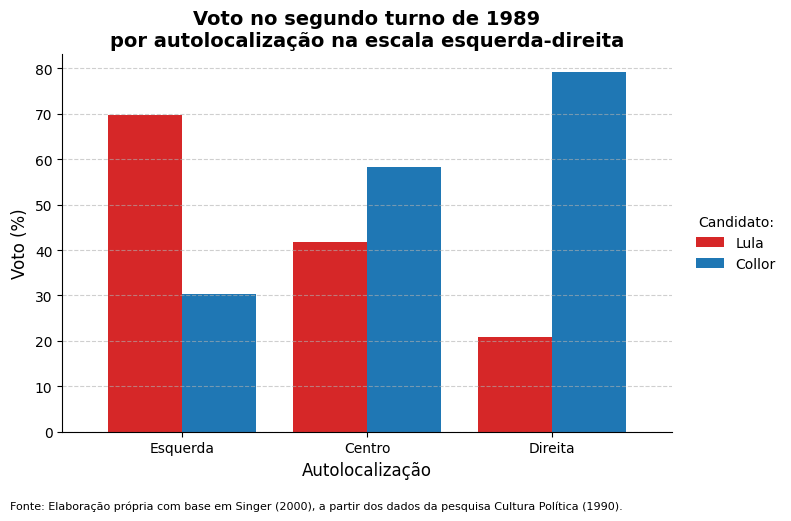

In [3]:
dados_pct = dados.div(dados.sum(axis=0), axis=1) * 100

dados_pct.index = ["Lula", "Collor"]

fig1, ax = plt.subplots(figsize=(8,5))

dados_pct.T.plot(
    kind="bar",
    color=["#d62728", "#1f77b4"],
    width=0.8,
    ax=ax
)

plt.title("Voto no segundo turno de 1989\npor autolocalização na escala esquerda-direita", fontsize=14, weight="bold")
plt.ylabel("Voto (%)", fontsize=12)
plt.xlabel("Autolocalização", fontsize=12)

plt.xticks(rotation=0, fontsize=10)
plt.yticks(fontsize=10)

plt.legend(title="Candidato:", fontsize=10, title_fontsize=10, loc = "center left", bbox_to_anchor=(1.02, 0.5), frameon=False)

plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.figtext(
    0.4, -0.03,
    "Fonte: Elaboração própria com base em Singer (2000), a partir dos dados da pesquisa Cultura Política (1990).",
    ha="center", fontsize=8)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

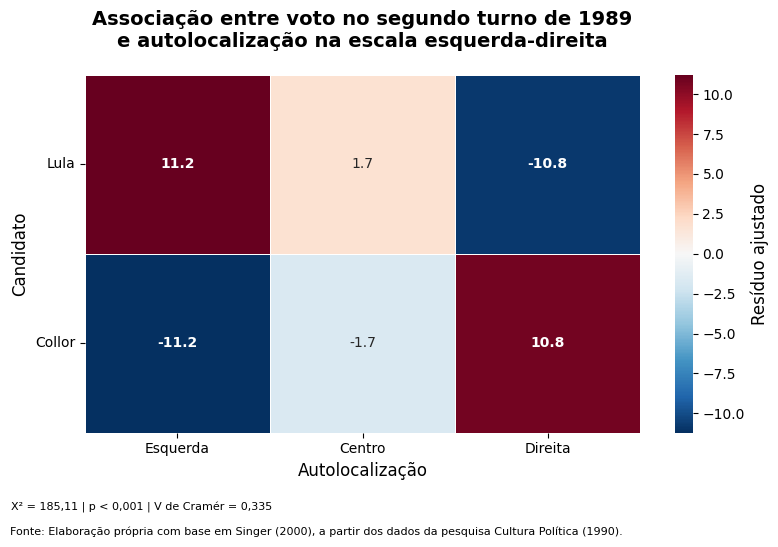

In [4]:
residuos_ajustados.index = ["Lula", "Collor"]

fig2, ax = plt.subplots(figsize=(8,5))

ax = sns.heatmap(
    residuos_ajustados,
    annot=True,
    fmt=".1f",
    center=0,
    cmap="RdBu_r",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Resíduo ajustado"}
)

cbar = ax.collections[0].colorbar
cbar.ax.yaxis.label.set_size(12) 
cbar.ax.tick_params(labelsize=10)

plt.title(
    "Associação entre voto no segundo turno de 1989\ne autolocalização na escala esquerda-direita",
    fontsize=14,
    weight="bold",
    pad=20
)

plt.xlabel("Autolocalização", fontsize=12)
plt.ylabel("Candidato", fontsize=12)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10, rotation=0)

for text in ax.texts:
    value = float(text.get_text())
    if abs(value) > 2:
        text.set_weight("bold")
    if abs(value) > 4:
        text.set_color("white")

plt.figtext(
    0.182, -0.03,
    "X² = 185,11 | p < 0,001 | V de Cramér = 0,335",
    ha="center",
    fontsize=8
)

plt.figtext(
    0.4, -0.08,
    "Fonte: Elaboração própria com base em Singer (2000), a partir dos dados da pesquisa Cultura Política (1990).",
    ha="center",
    fontsize=8
)

plt.tight_layout()
plt.show()

In [5]:
save_graph(fig1, "grafico_barras_voto_1989.png")

save_graph(fig2, "heatmap_residuos_ajustados_1989.png")